TensorFlow version: 2.19.0
GPU available: True — /physical_device:GPU:0
✅ All imports successful
✅ Utilities defined
Raw dataset: 6834 samples, 876 classes
After filtering singletons: 6013 samples, 55 classes
Cleaning text data...
After cleaning: 6013 samples

Text length stats (words):
  Mean:   20
  Median: 17
  95th:   38
  Max:    500

Augmenting classes with < 40 samples...
After augmentation: 6021 samples, 55 classes

Class distribution (top 10 & bottom 10):
  TOP 10:
    Common Cold                             : 192
    Varicose Veins                          : 190
    Pneumonia                               : 188
    Arthritis                               : 185
    Impetigo                                : 185
    Dengue                                  : 184
    Typhoid                                 : 184
    Bronchial Asthma                        : 183
    Migraine                                : 182
    Malaria                                 : 181
  BOTTOM 10:
    Cerv

Model: "NLP_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 38)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  3,840,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 38, 256)   │    327,936 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 38, 256)   │      1,024 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 19, 256)   │          0 │ bn_conv1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv1          │ (None, 19, 256)   │          0 │ pool1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 19, 128)   │     98,432 │ drop_conv1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv2            │ (None, 19, 128)   │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 9, 128)    │          0 │ bn_conv2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv2          │ (None, 9, 128)    │          0 │ pool2[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 9, 256)    │    263,168 │ drop_conv2[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 9, 256)    │          0 │ bilstm[0][0],     │
│ (Attention)         │                   │            │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_attn        │ (None, 2304)      │          0 │ attention[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ bilstm[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 2560)      │          0 │ flatten_attn[0][… │
│                     │                   │            │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_merge          │ (None, 2560)      │          0 │ merge[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 256)       │    655,616 │ drop_merge[0][0]

 Total params: 5,228,215 (19.94 MB)

 Trainable params: 5,226,679 (19.94 MB)

 Non-trainable params: 1,536 (6.00 KB)


  FOLD 1 / 5
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.1779 - loss: 3.7179 - val_accuracy: 0.0166 - val_loss: 4.4055 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7006 - loss: 1.4444 - val_accuracy: 0.0280 - val_loss: 4.9479 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8234 - loss: 0.8460 - val_accuracy: 0.0674 - val_loss: 4.2483 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8952 - loss: 0.5768 - val_accuracy: 0.6328 - val_loss: 1.5315 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9328 - loss: 0.4012 - val_accuracy: 0.8890 - val_loss: 0.5280 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9441 - loss: 0.3338 - val_accuracy: 0.9212 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accur

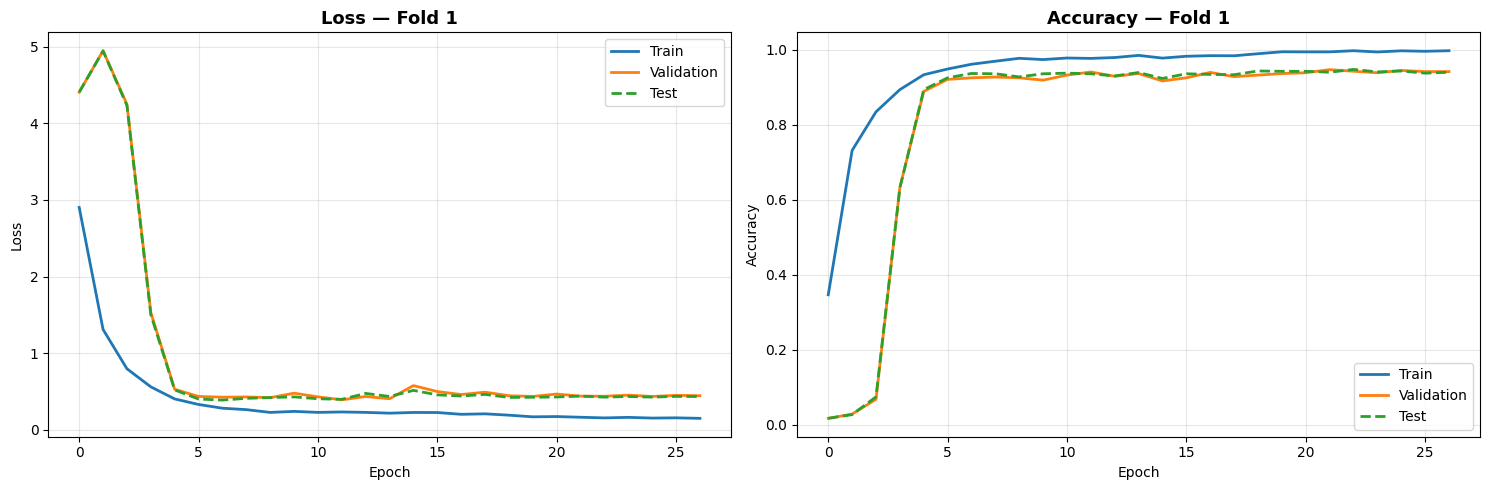


  FOLD 2 / 5
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.1866 - loss: 3.6706 - val_accuracy: 0.0415 - val_loss: 4.3712 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7076 - loss: 1.4399 - val_accuracy: 0.0249 - val_loss: 6.5018 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8114 - loss: 0.9136 - val_accuracy: 0.0945 - val_loss: 6.3929 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8952 - loss: 0.5501 - val_accuracy: 0.4258 - val_loss: 2.9329 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9368 - loss: 0.3958 - val_accuracy: 0.8775 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9487 - loss: 0.3254 - val_accuracy: 0.9283 - val_loss: 0.3932 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accura

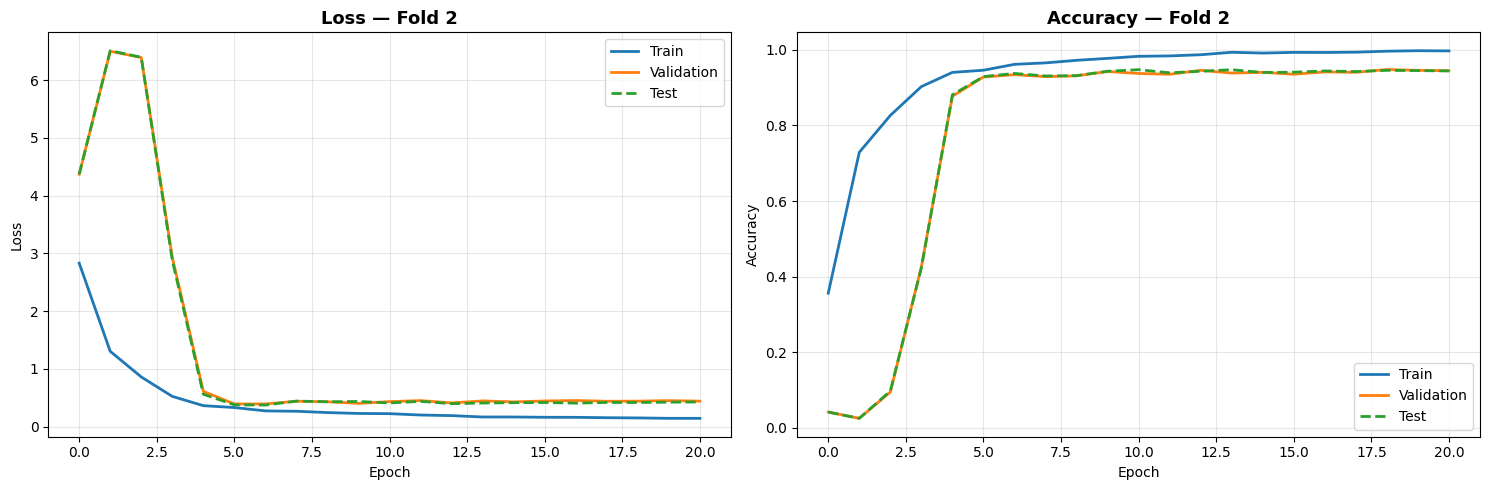


  FOLD 3 / 5
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.1999 - loss: 3.5900 - val_accuracy: 0.0166 - val_loss: 4.3987 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6852 - loss: 1.4724 - val_accuracy: 0.0415 - val_loss: 5.1149 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8400 - loss: 0.8367 - val_accuracy: 0.0467 - val_loss: 5.0887 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9009 - loss: 0.5520 - val_accuracy: 0.4829 - val_loss: 2.2348 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9319 - loss: 0.4028 - val_accuracy: 0.9024 - val_loss: 0.4837 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9498 - loss: 0.3381 - val_accuracy: 0.9252 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accura

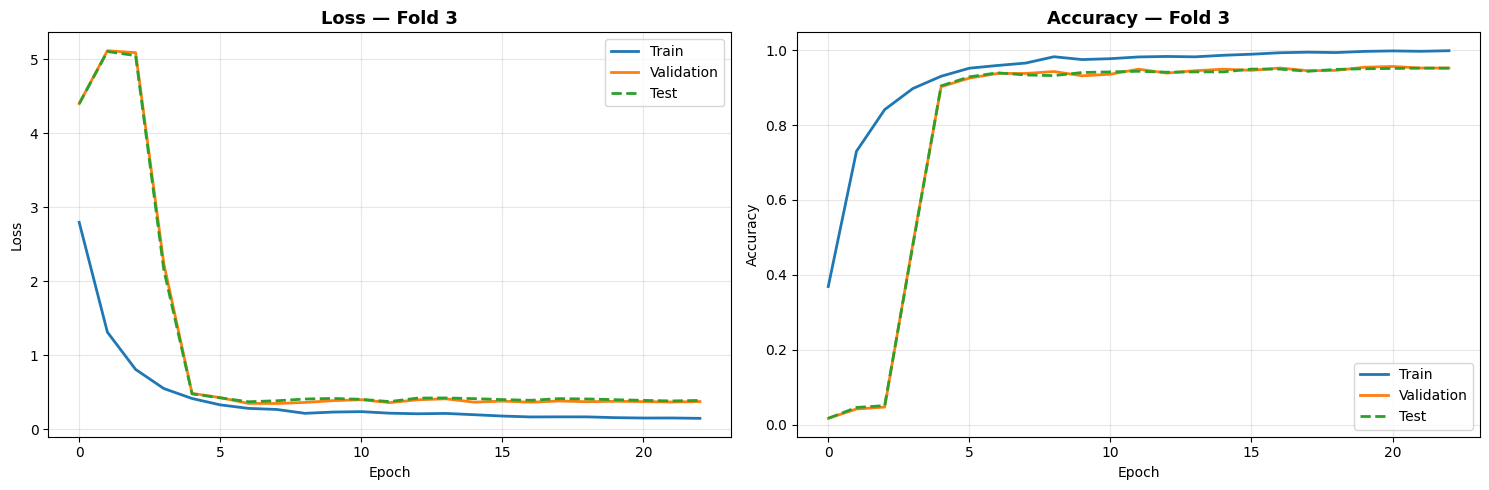


  FOLD 4 / 5
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.1795 - loss: 3.6677 - val_accuracy: 0.0166 - val_loss: 4.5143 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7012 - loss: 1.4547 - val_accuracy: 0.0166 - val_loss: 5.5705 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8128 - loss: 0.9023 - val_accuracy: 0.0301 - val_loss: 6.2114 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8856 - loss: 0.5784 - val_accuracy: 0.5213 - val_loss: 1.9447 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9253 - loss: 0.4080 - val_accuracy: 0.9148 - val_loss: 0.3964 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9450 - loss: 0.3378 - val_accuracy: 0.9252 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accura

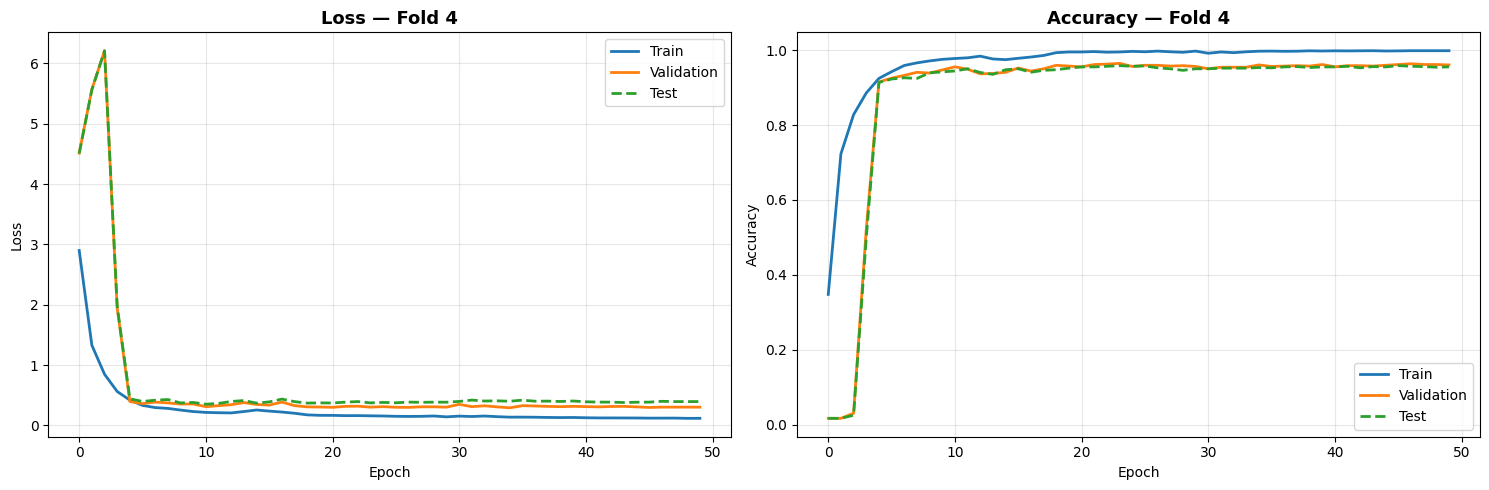


  FOLD 5 / 5
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.1782 - loss: 3.7034 - val_accuracy: 0.0332 - val_loss: 4.2798 - learning_rate: 0.0010
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7229 - loss: 1.3926 - val_accuracy: 0.0312 - val_loss: 5.1272 - learning_rate: 0.0010
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8282 - loss: 0.8427 - val_accuracy: 0.0488 - val_loss: 4.6329 - learning_rate: 0.0010
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8905 - loss: 0.5563 - val_accuracy: 0.5971 - val_loss: 1.6893 - learning_rate: 0.0010
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9324 - loss: 0.4143 - val_accuracy: 0.9169 - val_loss: 0.4026 - learning_rate: 0.0010
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9534 - loss: 0.3029 - val_accuracy: 0.9263 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accura

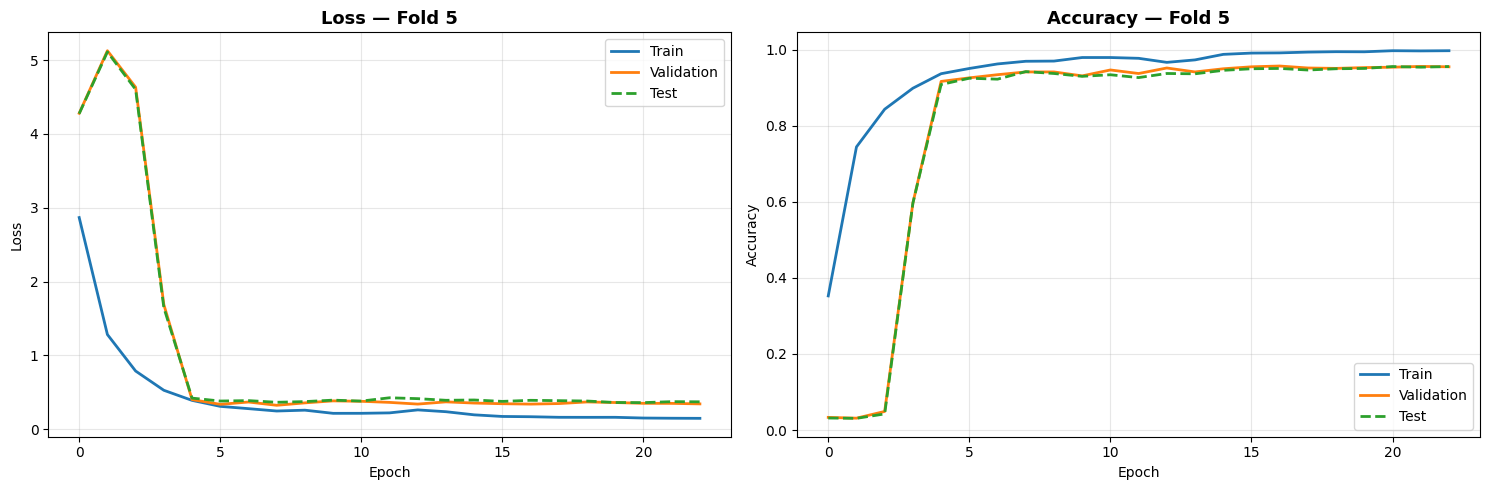


✅ Best model: Fold 4 (Val Acc: 0.9647)

  RETRAINING FINAL NLP MODEL ON ALL TRAIN+VAL DATA
Epoch 1/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.1811 - loss: 3.6732 - val_accuracy: 0.0104 - val_loss: 4.5257 - learning_rate: 0.0010
Epoch 2/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7111 - loss: 1.3623 - val_accuracy: 0.0207 - val_loss: 4.7933 - learning_rate: 0.0010
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8358 - loss: 0.7754 - val_accuracy: 0.1784 - val_loss: 3.3640 - learning_rate: 0.0010
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8961 - loss: 0.5371 - val_accuracy: 0.8755 - val_loss: 0.6286 - learning_rate: 0.0010
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9438 - loss: 0.3555 - val_accuracy: 0.9149 - val_loss: 0.4092 - learning_rate: 0.0010
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9576 - loss: 0.2983 - val_accuracy: 0.9108 - val_loss: 0.4697 - learni

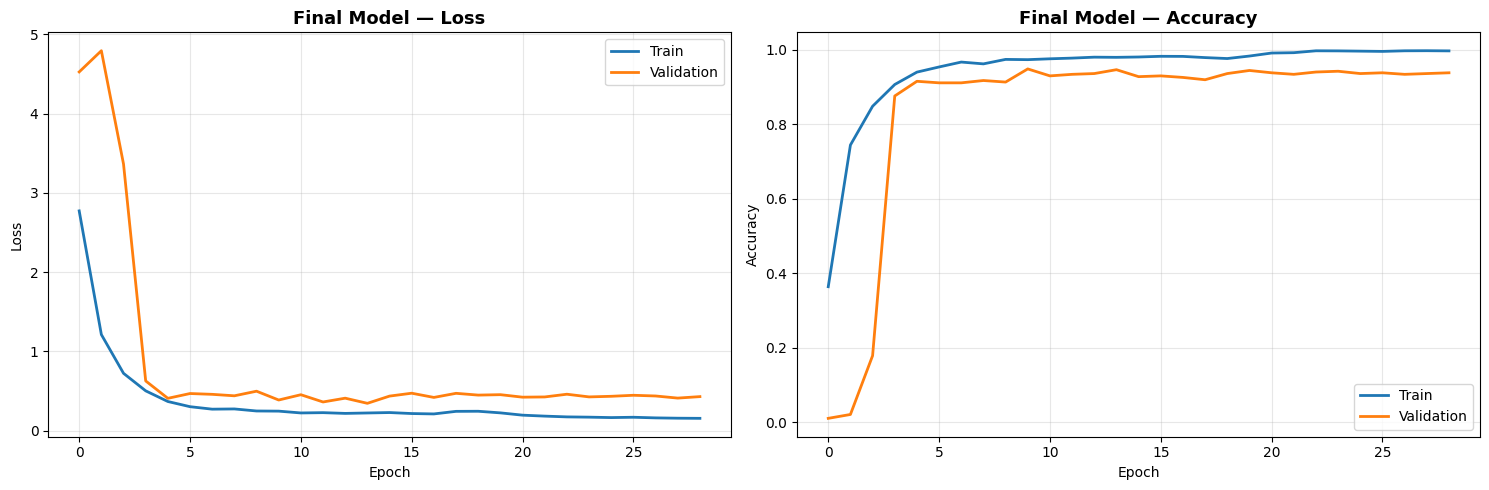


  Q3: NLP MODEL — AGGREGATE METRICS (5-FOLD CV)
  Train Loss               : 0.1413 ± 0.0129
  Train Acc                : 0.9979 ± 0.0005
  Val Loss                 : 0.3498 ± 0.0431
  Val Acc                  : 0.9547 ± 0.0073
  Test Loss                : 0.3854 ± 0.0145
  Test Acc                 : 0.9391 ± 0.0094
  Macro F1                 : 0.9063 ± 0.0151
  Roc Auc                  : 0.9975 ± 0.0007
  Top3                     : 0.9866 ± 0.0043
  Top5                     : 0.9939 ± 0.0026
  Ece                      : 0.032944 ± 0.007359
  Brier                    : 0.095820 ± 0.008477
  Sens Acute               : 0.9748 ± 0.0049
  Npv Acute                : 0.9993 ± 0.0001

  📄 Saved: nlp_fold_metrics.csv

  AGGREGATE CLASSIFICATION REPORT (all folds on test set):
                                         precision    recall  f1-score   support

(Vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        95
                                   Acne       0.99      1

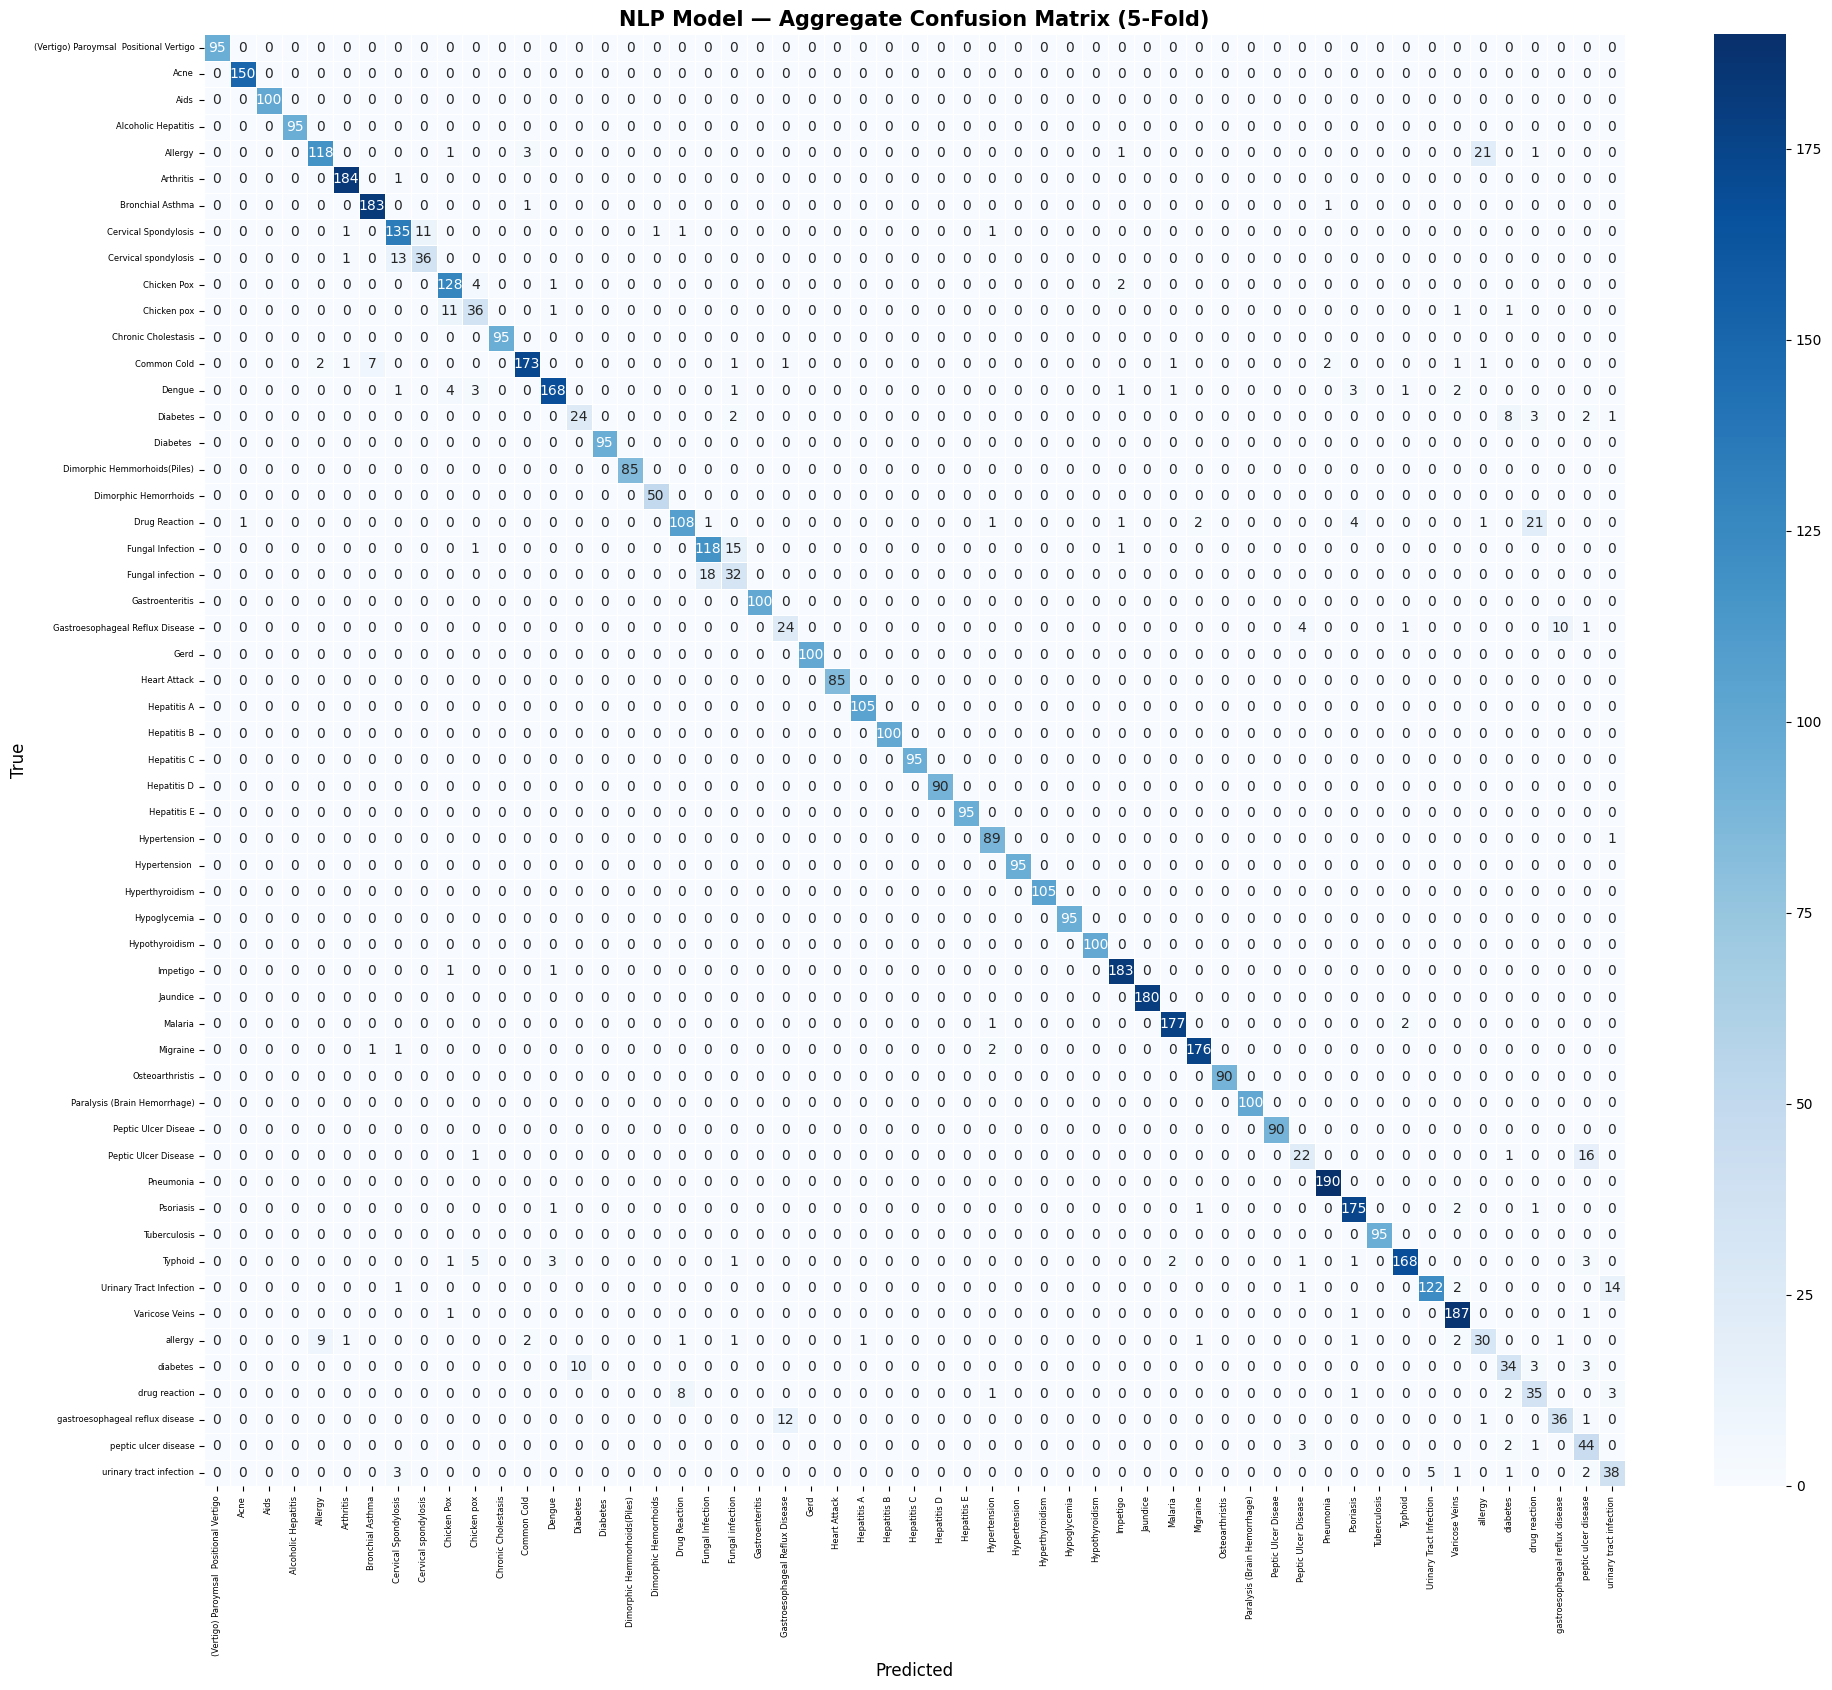

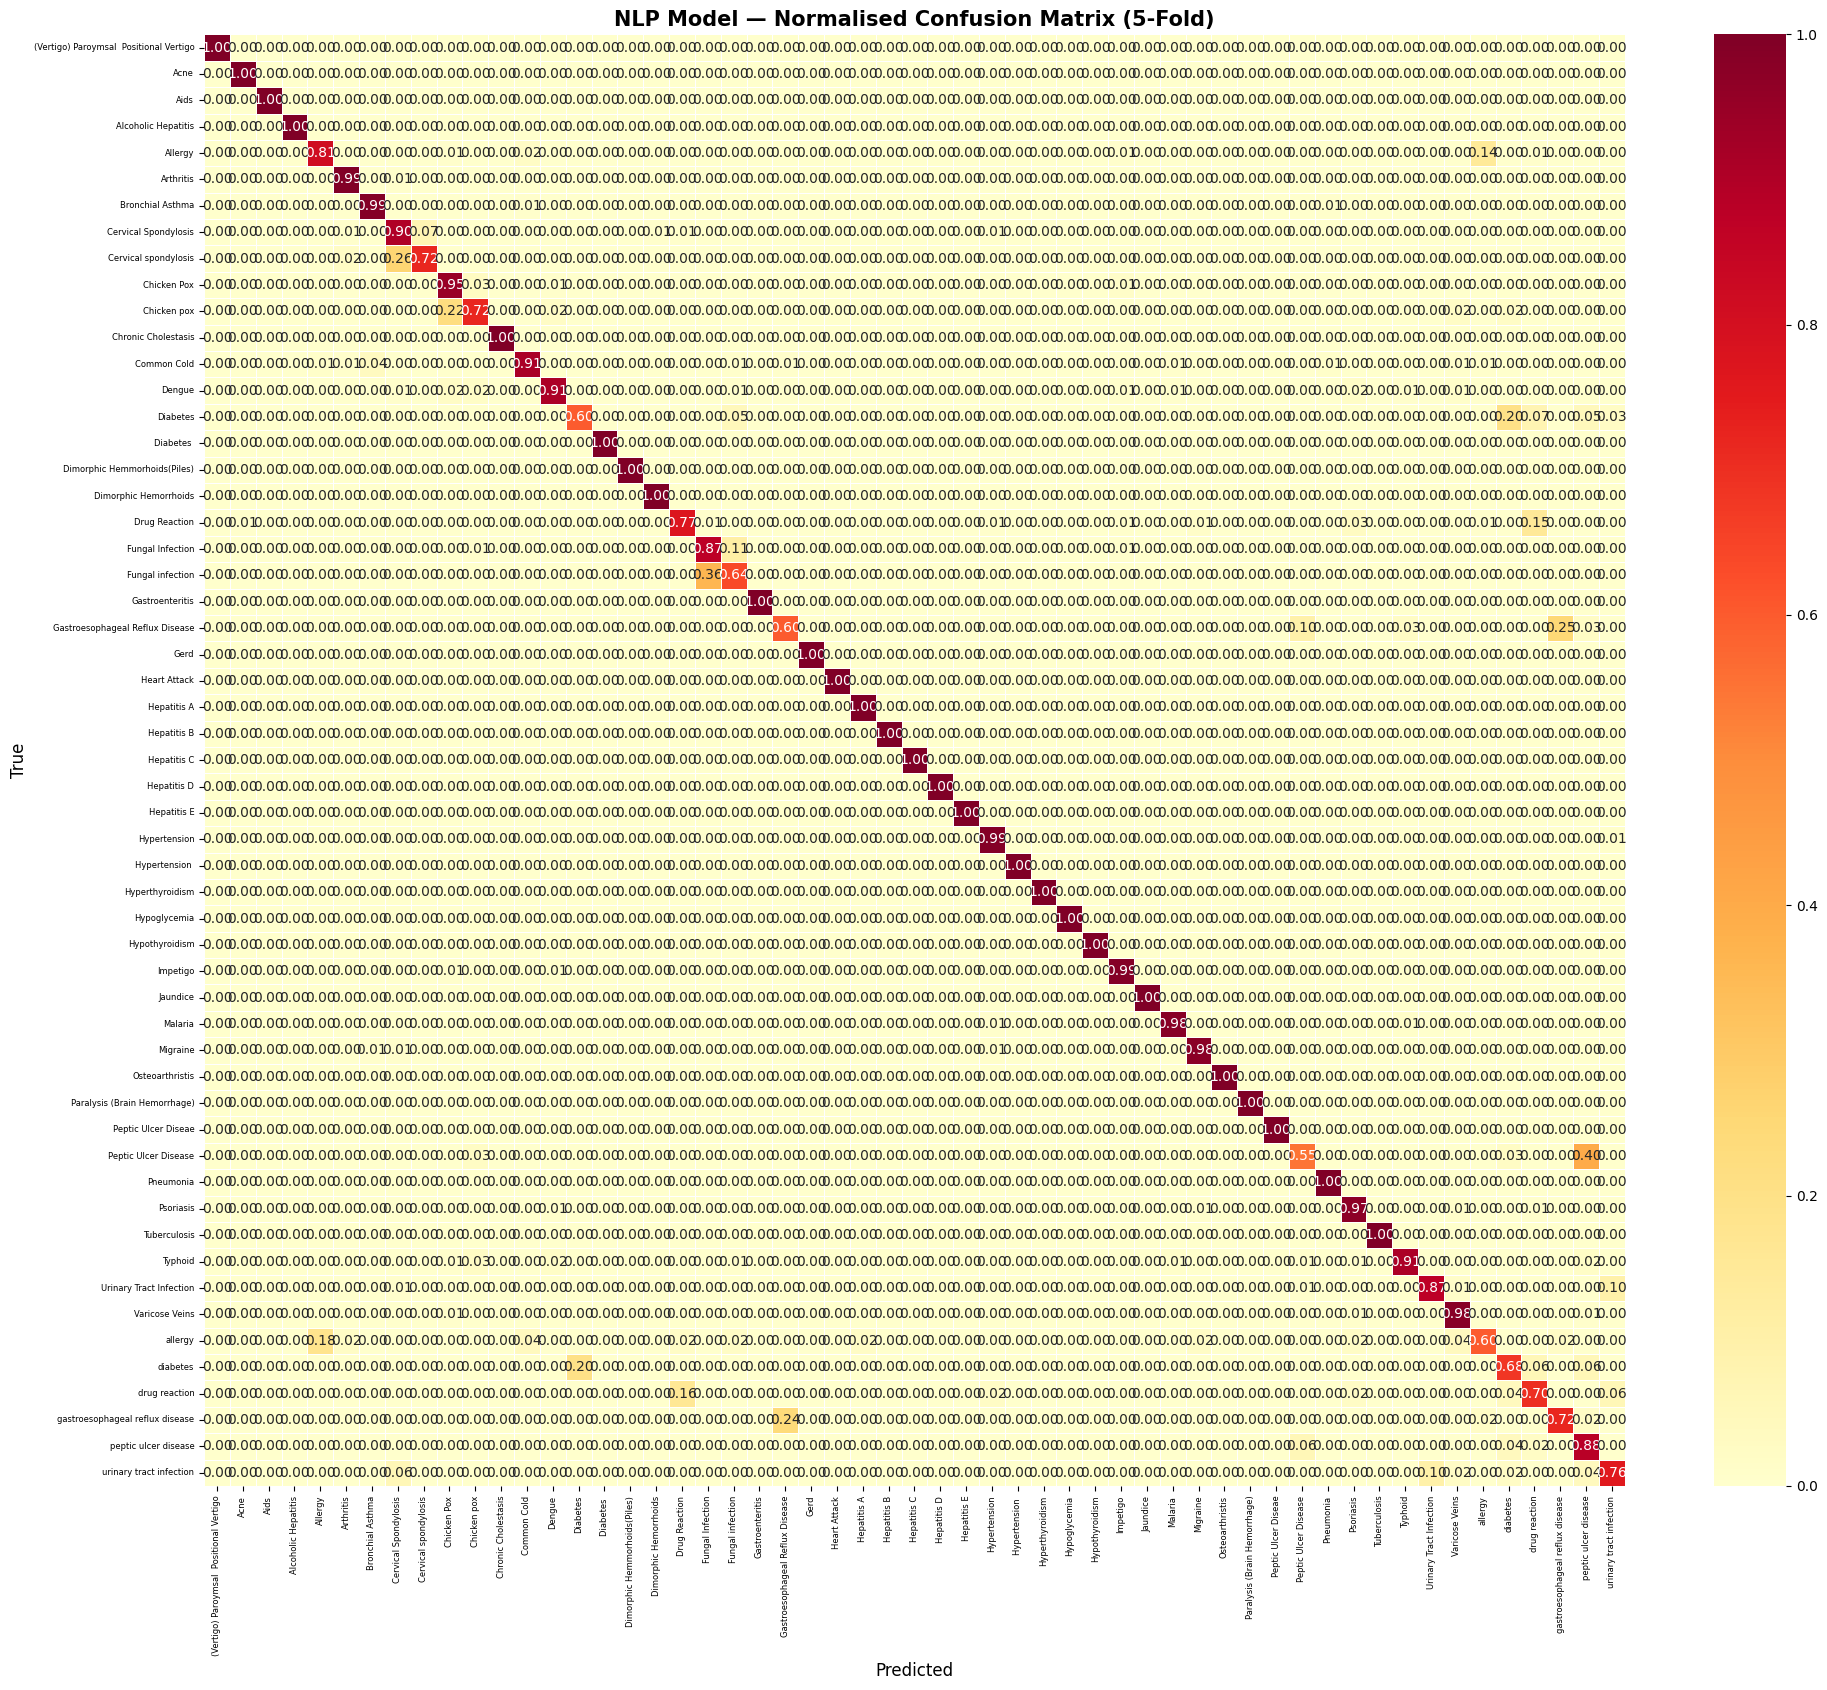

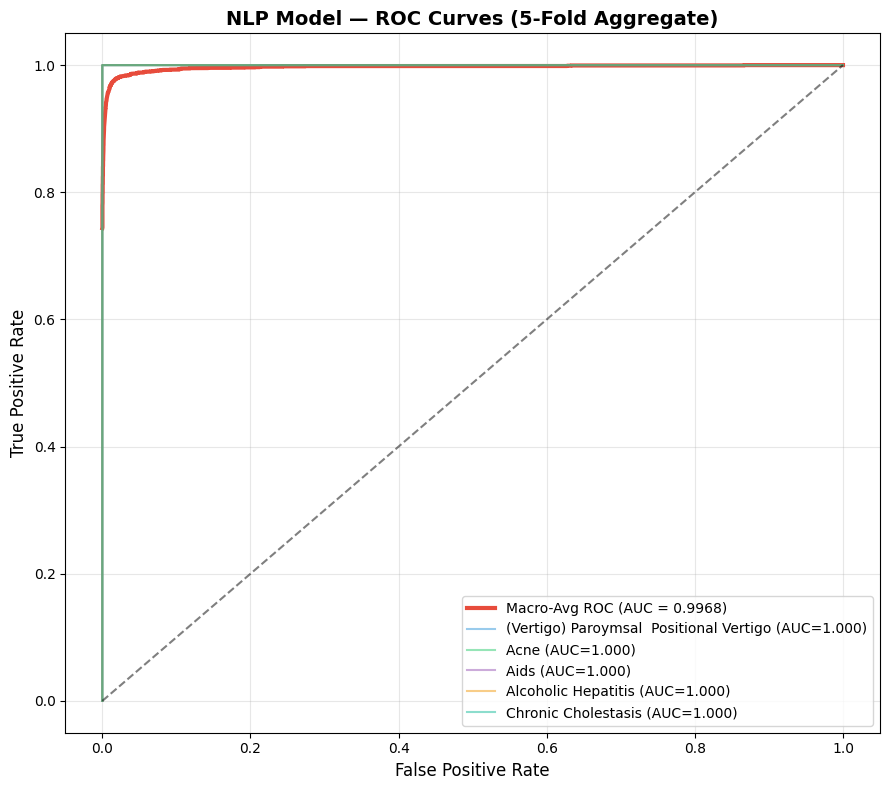

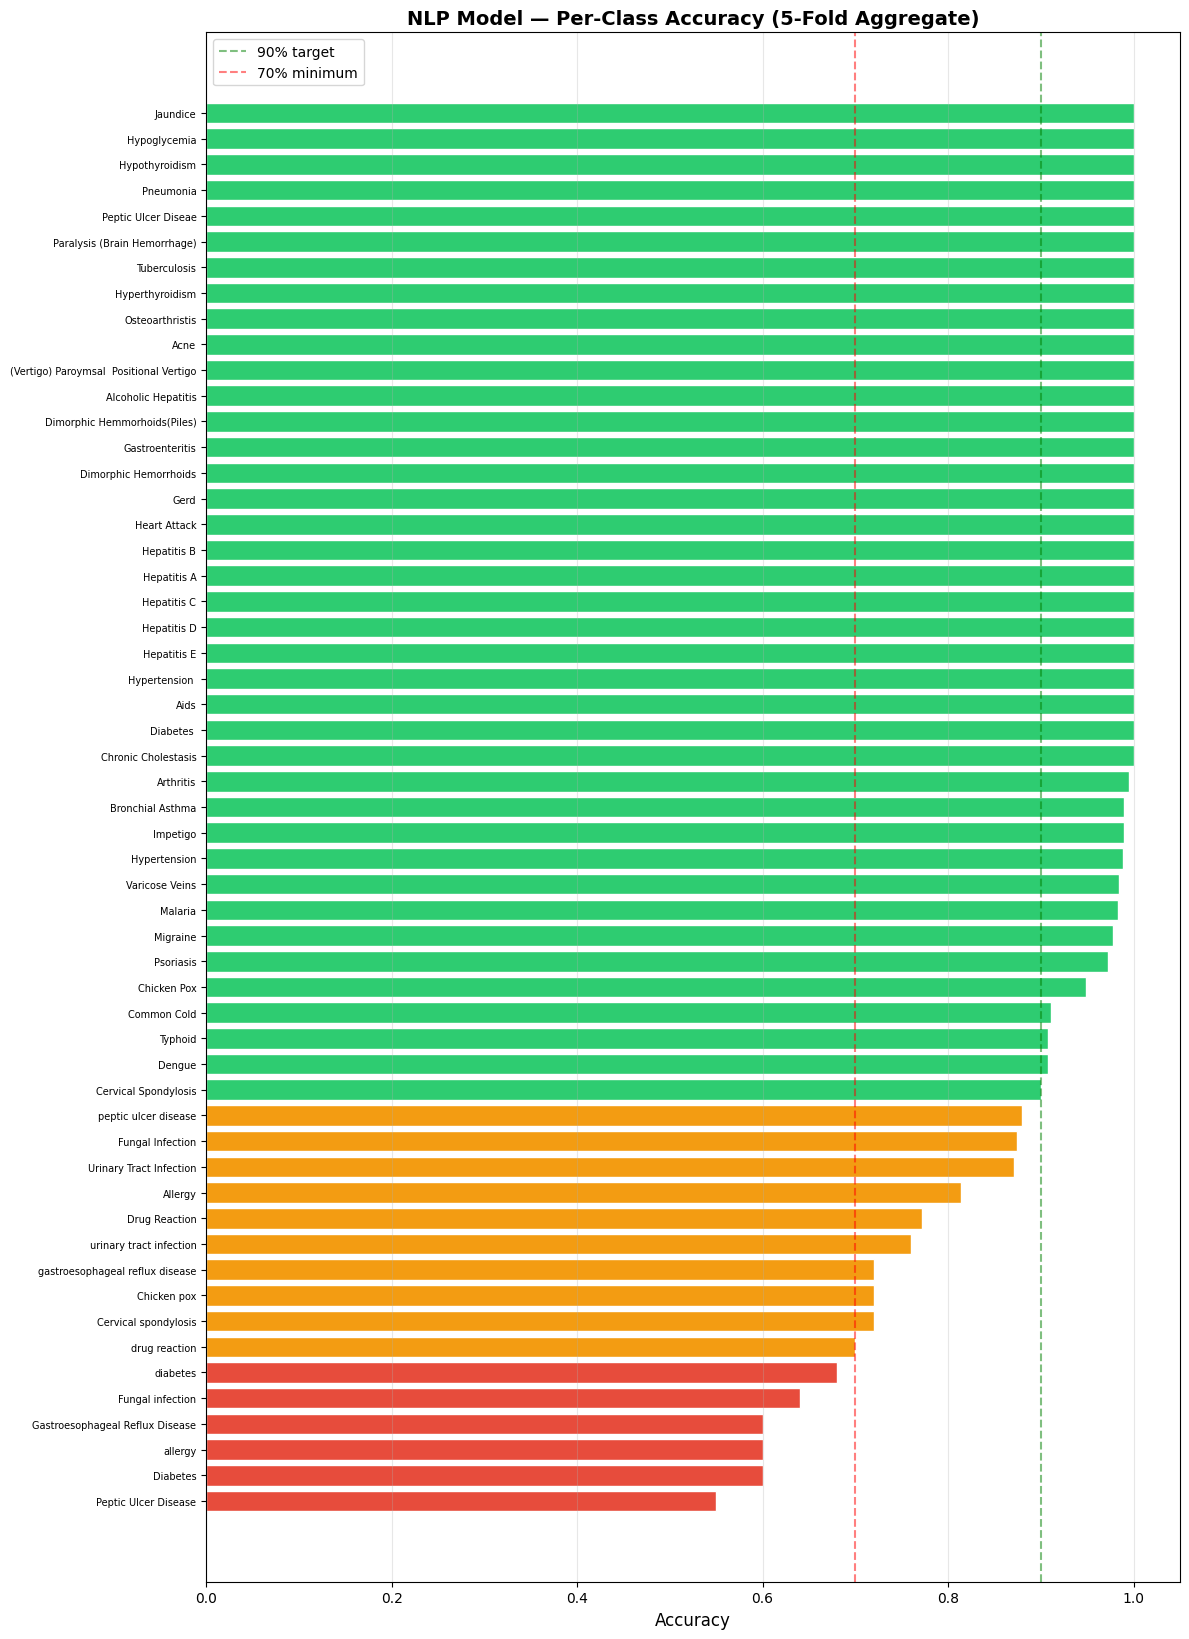

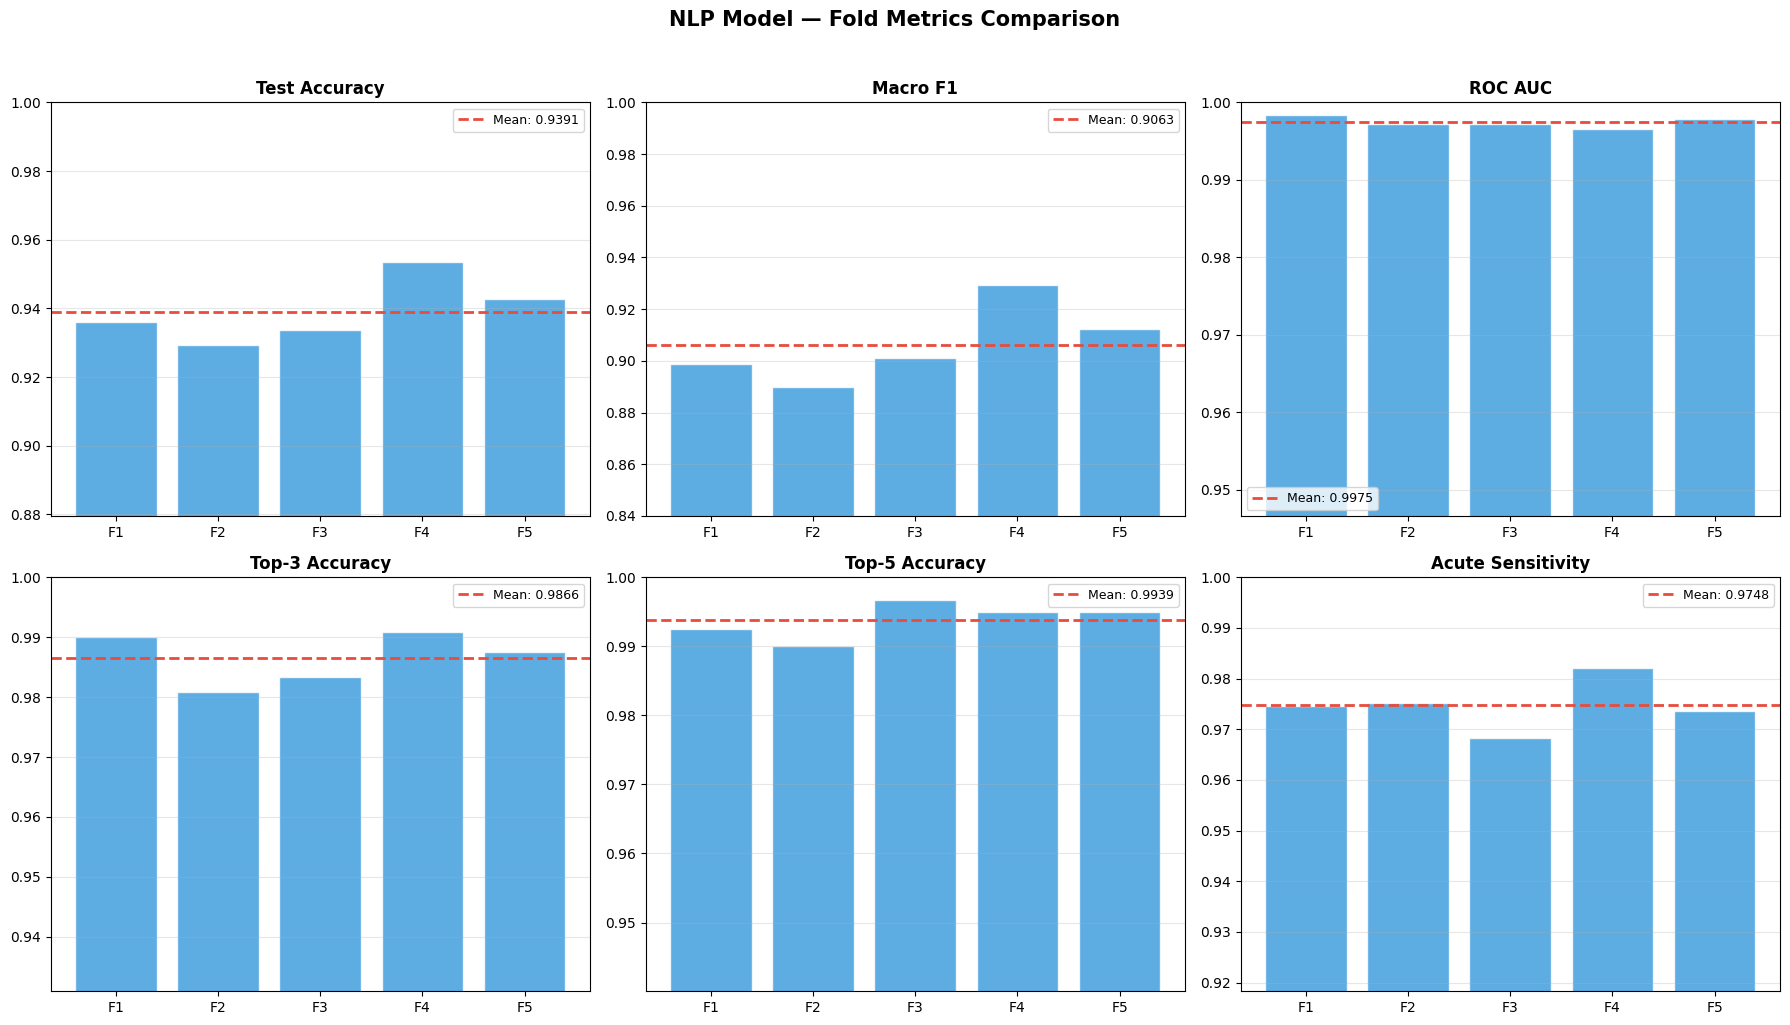


  Q4: CALIBRATION & COST-SENSITIVITY — NLP MODEL


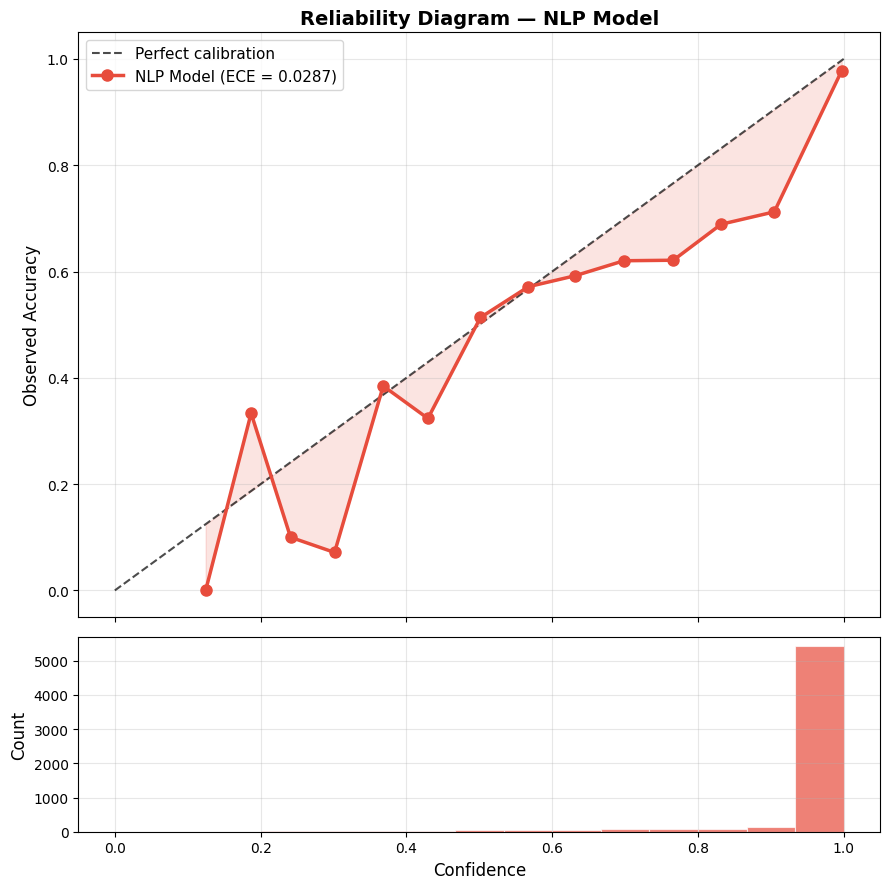


  ECE:   0.028673
  Brier: 0.095820


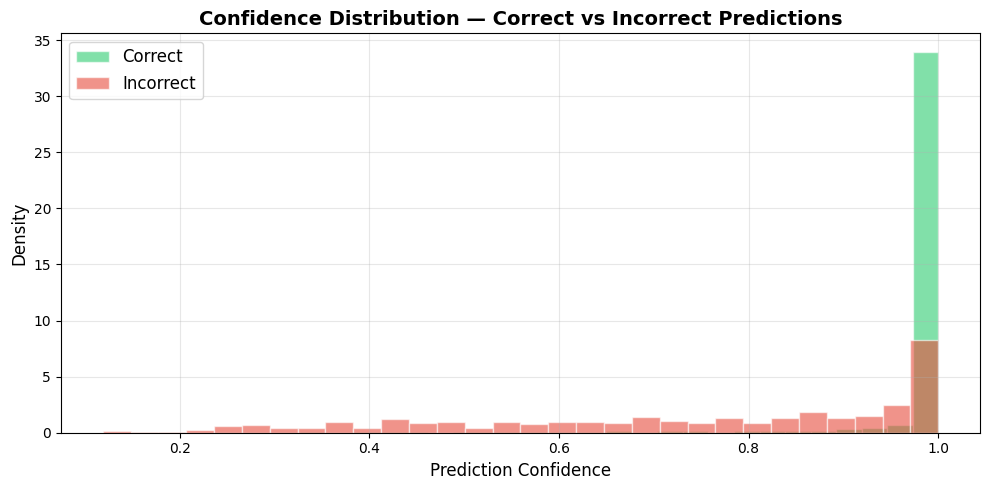


  Threshold Sweep (key thresholds):
  Threshold    Coverage     Accuracy     Acute FN     Rejection   
  ------------------------------------------------------------
  θ=0.500      0.9824       0.9510       0.0230       0.0176
  θ=0.700      0.9563       0.9606       0.0175       0.0437
  θ=0.800      0.9388       0.9668       0.0152       0.0612
  θ=0.900      0.9149       0.9755       0.0090       0.0851
  θ=0.950      0.8908       0.9804       0.0061       0.1092
  θ=0.975      0.8702       0.9844       0.0051       0.1298


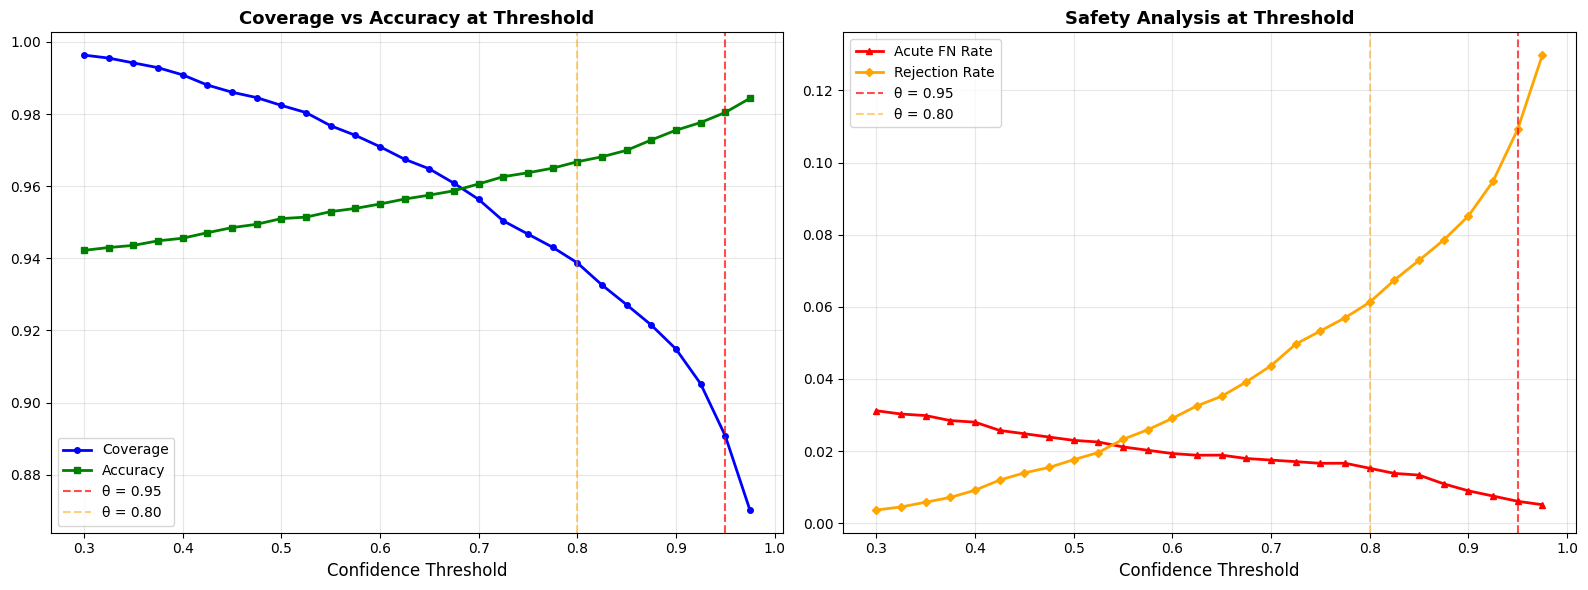


  Cost-Sensitive Analysis:
  Weighted cost/sample: 0.1734 ± 0.0277

  Cost Breakdown by Severity Tier:
    Critical    : Acc=1.0000 | Recall=1.0000 | Samples=285
    Moderate    : Acc=0.9408 | Recall=0.9464 | Samples=1165
    Chronic     : Acc=0.9693 | Recall=0.9473 | Samples=1140


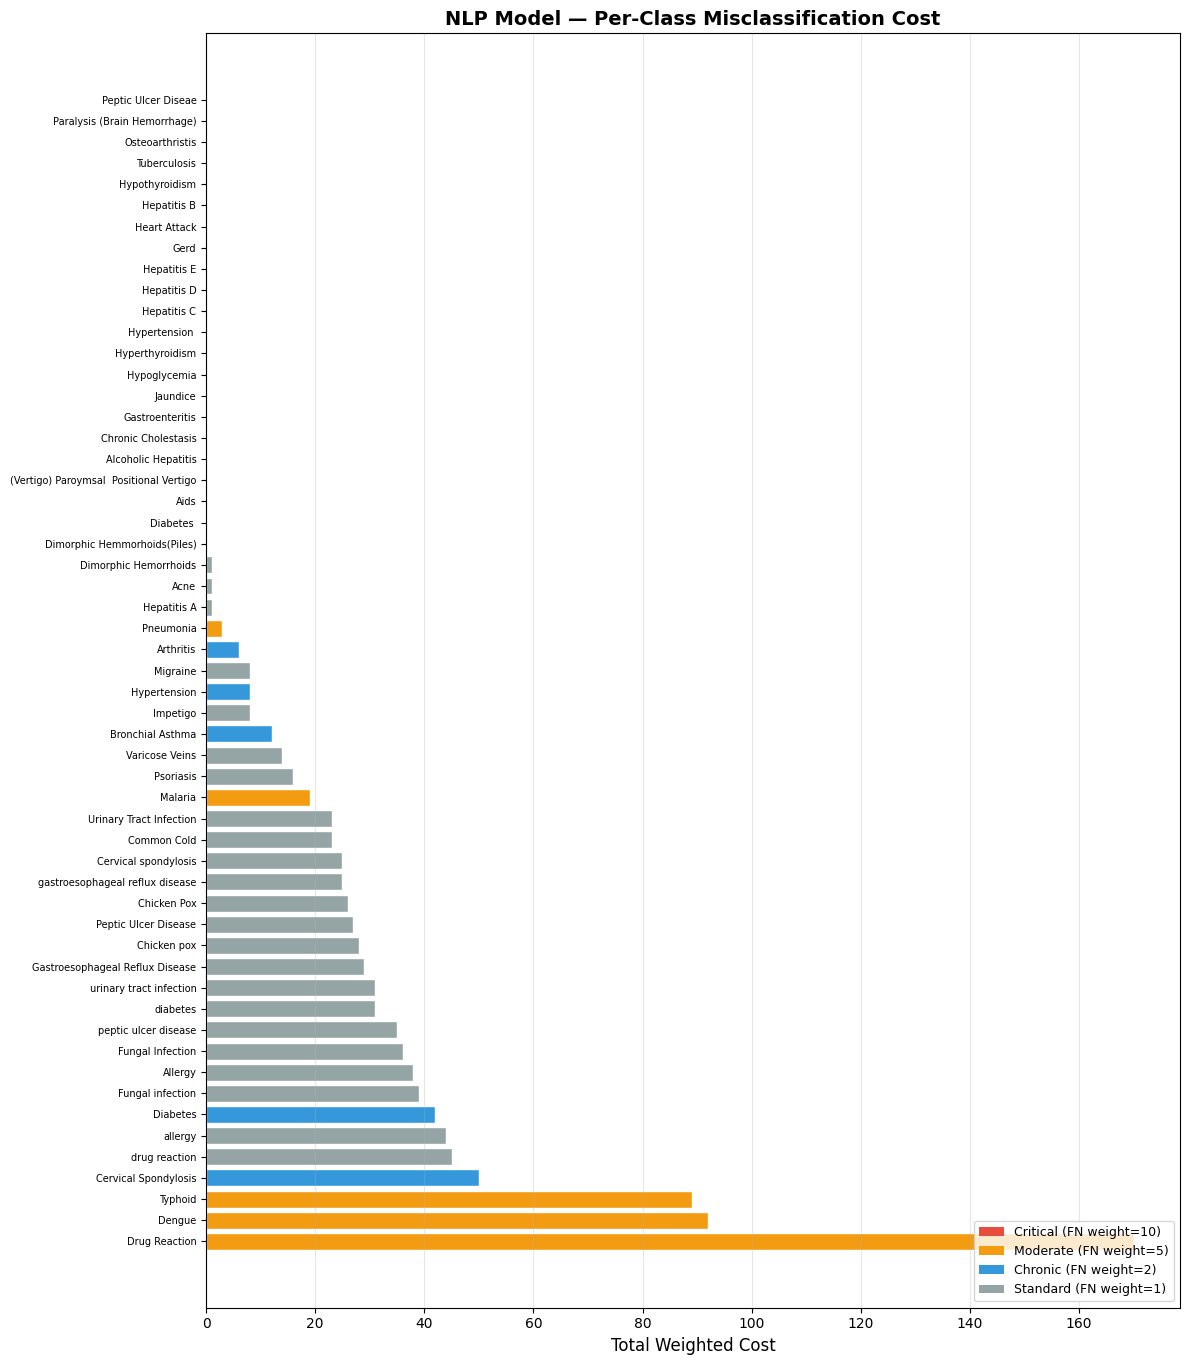


  COMPLETE NLP MODEL V2 SUMMARY

  Metric                          Mean      ± Std
  --------------------------------------------------
  Train Loss               : 0.1413 ± 0.0129
  Train Acc                : 0.9979 ± 0.0005
  Val Loss                 : 0.3498 ± 0.0431
  Val Acc                  : 0.9547 ± 0.0073
  Test Loss                : 0.3854 ± 0.0145
  Test Acc                 : 0.9391 ± 0.0094
  Macro F1                 : 0.9063 ± 0.0151
  Roc Auc                  : 0.9975 ± 0.0007
  Top3                     : 0.9866 ± 0.0043
  Top5                     : 0.9939 ± 0.0026
  Ece                      : 0.032944 ± 0.007359
  Brier                    : 0.095820 ± 0.008477
  Sens Acute               : 0.9748 ± 0.0049
  Npv Acute                : 0.9993 ± 0.0001
  Cost/Sample              : 0.1734 ± 0.0277
  Final Model Test Acc     : 0.9469
  Final Model Test Loss    : 0.3862

  📂 Saved Models:
     /content/saved_models/best_nlp_model.keras
     /content/saved_models/final_nlp_mode

In [1]:
"""
================================================================================
NB4: NLP MODEL V2 — TRAINING + MODEL SAVING + Q3 + Q4 COMPLETE
================================================================================
Fixes over V1:
  - Aggressive text cleaning (removes scraped HTML/web artifacts)
  - Normalises comma-separated symptom lists to readable text
  - Proper learning rate for training from scratch (1e-3 vs 3e-5)
  - Reduced over-regularisation (L2=1e-4, Dropout=0.2-0.25)
  - Dynamic maxlen based on actual text lengths
  - Higher augmentation threshold (40 samples per class)
  - validation ≠ test, 5-fold stratified CV, fresh model per fold
  - Softmax probs for ROC, saves best model + final retrained model

Outputs: saved models, fold metrics, reliability diagram, threshold sweep,
         cost analysis, confusion matrix, ROC, classification report,
         per-class accuracy bar chart, confidence distribution, training
         summary table.

Dataset: bert_train.csv (55 classes after filtering singletons)
Run on: Colab GPU

Estimated runtime: ~1.5–2 hours on free Colab T4 GPU
================================================================================
"""

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1: SETUP & IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════
import subprocess, sys

# Ensure nltk wordnet data is available
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import pickle
import shutil
import random
import warnings
import tensorflow as tf

# ── Keras imports (compatible with Keras 3 / TF 2.16+) ──
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, Flatten, MaxPooling1D,
    LSTM, Bidirectional, Attention, Embedding, BatchNormalization,
    GlobalAveragePooling1D, Concatenate, SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    recall_score, roc_auc_score, top_k_accuracy_score,
    roc_curve, auc as sk_auc, precision_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

from nltk.corpus import wordnet

warnings.filterwarnings('ignore')

# Create output directories
for d in ['/content/saved_models', '/content/figures', '/content/results']:
    os.makedirs(d, exist_ok=True)

# Check GPU
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU available: {len(gpus) > 0}" + (f" — {gpus[0].name}" if gpus else ""))
print("✅ All imports successful")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: UTILITY FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def clean_text(text):
    """Remove web scraping artifacts, HTML junk, and normalise text format."""
    if not isinstance(text, str):
        return ""

    # ── Remove pop-up / dialog artifacts ──
    text = re.sub(r'Open pop-up dialog box', ' ', text)
    text = re.sub(r'Close\s*\n?', ' ', text)

    # ── Remove Mayo Clinic boilerplate ──
    text = re.sub(r'By Mayo Clinic Staff.*?Staff', ' ', text, flags=re.DOTALL)
    text = re.sub(r'From Mayo Clinic to your inbox.*?Subscribe!', ' ', text, flags=re.DOTALL)
    text = re.sub(r'Sign up for free.*?Subscribe!', ' ', text, flags=re.DOTALL)
    text = re.sub(r'Request an appointment.*?resubmit the form\.?', ' ', text, flags=re.DOTALL)
    text = re.sub(r'Email\s+Error.*?email address', ' ', text, flags=re.DOTALL)
    text = re.sub(r'Learn more about Mayo Clinic.*?unsubscribe link in the e-mail\.?', ' ', text, flags=re.DOTALL)
    text = re.sub(r'Thank you for subscribing!?', ' ', text)
    text = re.sub(r'Explore Mayo Clinic studies.*?studies', ' ', text, flags=re.DOTALL)
    text = re.sub(r'Clinical trials.*?condition\.?', ' ', text, flags=re.DOTALL)
    text = re.sub(r'care at Mayo Clinic\s*', ' ', text)

    # ── Remove image/dialog repeated captions ──
    text = re.sub(r'(\b\w{5,}\b.{10,}?)\1{2,}', r'\1', text, flags=re.DOTALL)

    # ── Normalise comma-separated symptom lists ──
    tokens = text.strip().split(',')
    if len(tokens) >= 3 and all('_' in t.strip() or len(t.strip().split()) <= 2 for t in tokens):
        text = ', '.join(t.strip().replace('_', ' ') for t in tokens)

    # ── General cleanup ──
    text = re.sub(r'\s+', ' ', text).strip()

    # Truncate excessively long text to ~500 words
    words = text.split()
    if len(words) > 500:
        text = ' '.join(words[:500])

    return text


def ece_full(y_true, y_prob, n_bins=15):
    """Compute Expected Calibration Error with bin details."""
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    accuracies = (predictions == y_true).astype(float)

    ece = 0.0
    bin_accs, bin_confs, bin_counts = [], [], []
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        bl, bu = bin_boundaries[i], bin_boundaries[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= bl) & (confidences <= bu)
        else:
            mask = (confidences >= bl) & (confidences < bu)

        count = np.sum(mask)
        if count > 0:
            acc = np.mean(accuracies[mask])
            conf = np.mean(confidences[mask])
            ece += np.abs(conf - acc) * (count / len(confidences))
            bin_accs.append(acc)
            bin_confs.append(conf)
            bin_counts.append(count)

    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)


def brier_multi(y_ohe, y_prob):
    """Multiclass Brier score."""
    return np.mean(np.sum((y_prob - y_ohe) ** 2, axis=1))


class TestCallback(Callback):
    """Track test loss/accuracy after each epoch (for plotting only)."""
    def __init__(self, X_test, y_test_ohe):
        super().__init__()
        self.X_test = X_test
        self.y_test_ohe = y_test_ohe
        self.test_losses = []
        self.test_accs = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test_ohe, verbose=0)
        self.test_losses.append(loss)
        self.test_accs.append(acc)


print("✅ Utilities defined")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: DATA LOADING, CLEANING & AUGMENTATION
# ═══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv('/content/bert_train.csv')
print(f"Raw dataset: {len(df)} samples, {df['Label'].nunique()} classes")

# ── Filter singleton classes (can't stratify with count=1) ──
vc = df['Label'].value_counts()
df = df[df['Label'].isin(vc[vc > 1].index)].copy()
print(f"After filtering singletons: {len(df)} samples, {df['Label'].nunique()} classes")

# ── Clean text ──
print("Cleaning text data...")
df['text'] = df['text'].apply(clean_text)

# Remove any rows with empty text after cleaning
df = df[df['text'].str.len() > 5].copy()
print(f"After cleaning: {len(df)} samples")

# ── Print text length statistics ──
lengths = [len(t.split()) for t in df['text'].values]
print(f"\nText length stats (words):")
print(f"  Mean:   {np.mean(lengths):.0f}")
print(f"  Median: {np.median(lengths):.0f}")
print(f"  95th:   {np.percentile(lengths, 95):.0f}")
print(f"  Max:    {np.max(lengths)}")

# ── Synonym-based augmentation ──
AUG_THRESH = 40

def synonym_replace(text, n=2):
    """Replace up to n words with synonyms for data augmentation."""
    words = text.split()
    new_words = words.copy()
    candidates = list(set([w for w in words if wordnet.synsets(w) and len(w) > 3]))
    random.shuffle(candidates)
    replacements = 0
    for word in candidates:
        synsets = wordnet.synsets(word)
        if synsets:
            lemmas = synsets[0].lemmas()
            if len(lemmas) > 1:
                synonym = lemmas[1].name().replace('_', ' ')
            else:
                synonym = lemmas[0].name().replace('_', ' ')
            if synonym.lower() != word.lower():
                new_words = [synonym if w == word else w for w in new_words]
                replacements += 1
        if replacements >= n:
            break
    return ' '.join(new_words)


def random_insert(text, n=1):
    """Insert a random synonym of a random word at a random position."""
    words = text.split()
    candidates = [w for w in words if wordnet.synsets(w) and len(w) > 3]
    new_words = words.copy()
    for _ in range(min(n, len(candidates))):
        if not candidates:
            break
        word = random.choice(candidates)
        synsets = wordnet.synsets(word)
        if synsets and synsets[0].lemmas():
            synonym = synsets[0].lemmas()[0].name().replace('_', ' ')
            pos = random.randint(0, len(new_words))
            new_words.insert(pos, synonym)
    return ' '.join(new_words)


def random_swap(text, n=2):
    """Randomly swap n pairs of words in the text."""
    words = text.split()
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2:
            break
        i, j = random.sample(range(len(new_words)), 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return ' '.join(new_words)


print(f"\nAugmenting classes with < {AUG_THRESH} samples...")
aug_rows = []
for label, count in df['Label'].value_counts().items():
    if count < AUG_THRESH:
        sub = df[df['Label'] == label]
        aug_funcs = [synonym_replace, random_insert, random_swap]
        while count < AUG_THRESH:
            for _, row in sub.iterrows():
                fn = random.choice(aug_funcs)
                aug_rows.append({
                    'Label': label,
                    'text': fn(row['text'])
                })
                count += 1
                if count >= AUG_THRESH:
                    break

df = pd.concat([df, pd.DataFrame(aug_rows)], ignore_index=True)
print(f"After augmentation: {len(df)} samples, {df['Label'].nunique()} classes")

# ── Print class distribution ──
print(f"\nClass distribution (top 10 & bottom 10):")
vc_final = df['Label'].value_counts()
print("  TOP 10:")
for lbl, cnt in vc_final.head(10).items():
    print(f"    {lbl:<40s}: {cnt}")
print("  BOTTOM 10:")
for lbl, cnt in vc_final.tail(10).items():
    print(f"    {lbl:<40s}: {cnt}")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: TOKENISATION & ENCODING
# ═══════════════════════════════════════════════════════════════════════════════
X_text = df['text'].values
y_labels = df['Label'].values

# ── Tokeniser ──
VOCAB_SIZE = 15000
tok = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tok.fit_on_texts(X_text)

# ── Dynamic maxlen: 95th percentile of word counts, capped at 150 ──
word_counts = [len(t.split()) for t in X_text]
MAXLEN = min(int(np.percentile(word_counts, 95)), 150)
print(f"\nUsing MAXLEN = {MAXLEN} (95th percentile, capped at 150)")

X_pad = pad_sequences(
    tok.texts_to_sequences(X_text),
    maxlen=MAXLEN, padding='post', truncating='post'
)

# ── Label encoding ──
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
NC = len(le.classes_)
print(f"Number of classes: {NC}")

# ── Strict train/test split (test set is NEVER used in training) ──
X_tv, X_te, y_tv, y_te = train_test_split(
    X_pad, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
y_te_ohe = to_categorical(y_te, NC)
print(f"Train+Val: {len(X_tv)} | Test: {len(X_te)}")

# ── Class weights ──
cw = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
cw_dict = {i: w for i, w in enumerate(cw)}

# ── Define acute/critical conditions ──
acute_labels = [
    'Heart Attack', 'Pneumonia', 'Tuberculosis', 'Typhoid', 'Hepatitis E',
    'Dengue', 'Malaria', 'Jaundice', 'Paralysis (Brain Hemorrhage)',
    'Alcoholic Hepatitis', 'Drug Reaction', 'Gastroenteritis',
    'Hepatitis A', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Aids'
]
acute_idx = [np.where(le.classes_ == l)[0][0] for l in acute_labels if l in le.classes_]
print(f"Acute conditions tracked: {len(acute_idx)}")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: MODEL DEFINITION
# ═══════════════════════════════════════════════════════════════════════════════

def build_nlp_model():
    """
    CNN + BiLSTM + Attention model with optimised regularisation.
    Key changes vs V1:
      - Learning rate: 1e-3 (proper for from-scratch training)
      - L2 regularisation: 1e-4 (100x lighter)
      - Dropout: 0.2-0.25 (reduced from 0.3-0.4)
      - SpatialDropout1D on embedding
      - Dual-path: Flatten(Attention) + GAP(LSTM) → concatenate
    """
    inp = Input(shape=(MAXLEN,), name='input')

    # ── Embedding ──
    x = Embedding(VOCAB_SIZE, 256, input_length=MAXLEN, name='embedding')(inp)
    x = SpatialDropout1D(0.15, name='spatial_dropout')(x)

    # ── CNN branch ──
    c = Conv1D(256, 5, activation='relu', padding='same',
               kernel_regularizer=l2(1e-4), name='conv1')(x)
    c = BatchNormalization(name='bn_conv1')(c)
    c = MaxPooling1D(2, name='pool1')(c)
    c = Dropout(0.2, name='drop_conv1')(c)

    c = Conv1D(128, 3, activation='relu', padding='same',
               kernel_regularizer=l2(1e-4), name='conv2')(c)
    c = BatchNormalization(name='bn_conv2')(c)
    c = MaxPooling1D(2, name='pool2')(c)
    c = Dropout(0.2, name='drop_conv2')(c)

    # ── BiLSTM + Attention ──
    # NOTE: recurrent_dropout removed — not supported by CuDNN on GPU
    lstm_out = Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.15),
        name='bilstm'
    )(c)
    attn = Attention(name='attention')([lstm_out, lstm_out])

    # ── Pooling paths ──
    flat = Flatten(name='flatten_attn')(attn)
    gap = GlobalAveragePooling1D(name='gap')(lstm_out)

    # ── Concatenate ──
    merged = Concatenate(name='merge')([flat, gap])
    merged = Dropout(0.2, name='drop_merge')(merged)

    # ── Dense head ──
    d = Dense(256, activation='relu', kernel_regularizer=l2(1e-4), name='dense1')(merged)
    d = BatchNormalization(name='bn_dense1')(d)
    d = Dropout(0.25, name='drop_dense1')(d)

    d = Dense(128, activation='relu', kernel_regularizer=l2(1e-4), name='dense2')(d)
    d = BatchNormalization(name='bn_dense2')(d)
    d = Dropout(0.2, name='drop_dense2')(d)

    out = Dense(NC, activation='softmax', name='output')(d)

    model = Model(inp, out, name='NLP_v2')
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Print model summary
_tmp = build_nlp_model()
_tmp.summary()
del _tmp


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: 5-FOLD CROSS-VALIDATION
# ═══════════════════════════════════════════════════════════════════════════════
EPOCHS = 100
BATCH_SIZE = 32

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
fold_predictions = []
all_y_true, all_y_pred, all_y_prob = [], [], []
agg_cm = np.zeros((NC, NC), dtype=int)
best_val_acc, best_fold_idx = -1, -1

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tv, y_tv)):
    print(f"\n{'=' * 60}")
    print(f"  FOLD {fold + 1} / 5")
    print(f"{'=' * 60}")

    X_train, X_val = X_tv[train_idx], X_tv[val_idx]
    y_train, y_val = y_tv[train_idx], y_tv[val_idx]
    y_train_ohe = to_categorical(y_train, NC)
    y_val_ohe = to_categorical(y_val, NC)

    # ── Fresh model per fold ──
    model = build_nlp_model()

    ckpt_path = f'/content/saved_models/nlp_fold_{fold + 1}.keras'
    test_cb = TestCallback(X_te, y_te_ohe)

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=6, min_lr=1e-6, verbose=1
        ),
        ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, mode='max', verbose=0
        ),
        test_cb
    ]

    history = model.fit(
        X_train, y_train_ohe,
        validation_data=(X_val, y_val_ohe),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=cw_dict,
        callbacks=callbacks,
        verbose=1
    )

    # ── Evaluate on held-out test set ──
    test_loss, test_acc = model.evaluate(X_te, y_te_ohe, verbose=0)
    y_prob = model.predict(X_te, verbose=0)
    y_pred_classes = np.argmax(y_prob, axis=1)

    # ── Track best fold ──
    val_acc = max(history.history['val_accuracy'])
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_fold_idx = fold

    # ── Aggregate results ──
    cm = confusion_matrix(y_te, y_pred_classes, labels=range(NC))
    agg_cm += cm
    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred_classes)
    all_y_prob.append(y_prob)
    fold_predictions.append({
        'y_true': y_te.copy(),
        'y_pred_prob': y_prob.copy()
    })

    # ── Compute metrics ──
    macro_f1 = f1_score(y_te, y_pred_classes, average='macro')
    top3 = top_k_accuracy_score(y_te, y_prob, k=3)
    top5 = top_k_accuracy_score(y_te, y_prob, k=5)
    ece_val, _, _, _ = ece_full(y_te, y_prob)
    brier = brier_multi(y_te_ohe, y_prob)

    try:
        roc_auc = roc_auc_score(y_te_ohe, y_prob, average='macro', multi_class='ovr')
    except Exception:
        roc_auc = 0.0

    # Acute-specific metrics
    sens_acute = recall_score(
        y_te, y_pred_classes, labels=acute_idx,
        average='macro', zero_division=0
    )
    npv_values = []
    for idx in acute_idx:
        tp = cm[idx, idx]
        fn = np.sum(cm[idx, :]) - tp
        tn = np.sum(cm) - np.sum(cm[idx, :]) - np.sum(cm[:, idx]) + tp
        npv_values.append(tn / (tn + fn) if (tn + fn) > 0 else 0)
    npv_acute = np.mean(npv_values) if npv_values else 0.0

    print(f"\n  Test Acc:  {test_acc:.4f} | Macro F1: {macro_f1:.4f} | AUC: {roc_auc:.4f}")
    print(f"  Top-3:    {top3:.4f} | Top-5:   {top5:.4f}")
    print(f"  ECE:      {ece_val:.6f} | Brier:   {brier:.6f}")
    print(f"  Acute Sensitivity: {sens_acute:.4f} | NPV: {npv_acute:.4f}")

    fold_results.append({
        'train_loss': history.history['loss'][-1],
        'train_acc': history.history['accuracy'][-1],
        'val_loss': min(history.history['val_loss']),
        'val_acc': val_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'macro_f1': macro_f1,
        'roc_auc': roc_auc,
        'top3': top3,
        'top5': top5,
        'ece': ece_val,
        'brier': brier,
        'sens_acute': sens_acute,
        'npv_acute': npv_acute
    })

    # ── Per-fold training curves ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Train', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax1.plot(test_cb.test_losses, label='Test', linewidth=2, linestyle='--')
    ax1.set_title(f'Loss — Fold {fold + 1}', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax2.plot(test_cb.test_accs, label='Test', linewidth=2, linestyle='--')
    ax2.set_title(f'Accuracy — Fold {fold + 1}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/content/figures/nlp_fold_{fold + 1}.png', dpi=200, bbox_inches='tight')
    plt.show()

# ── Save best fold model ──
shutil.copy(
    f'/content/saved_models/nlp_fold_{best_fold_idx + 1}.keras',
    '/content/saved_models/best_nlp_model.keras'
)
print(f"\n✅ Best model: Fold {best_fold_idx + 1} (Val Acc: {best_val_acc:.4f})")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: RETRAIN FINAL MODEL ON ALL TRAIN+VAL DATA
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 60}")
print(f"  RETRAINING FINAL NLP MODEL ON ALL TRAIN+VAL DATA")
print(f"{'=' * 60}")

y_tv_ohe = to_categorical(y_tv, NC)
final_model = build_nlp_model()

final_history = final_model.fit(
    X_tv, y_tv_ohe,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_dict,
    callbacks=[
        EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=6, min_lr=1e-6, verbose=1
        ),
    ],
    verbose=1
)

final_loss, final_acc = final_model.evaluate(X_te, y_te_ohe, verbose=0)
print(f"\n  Final Model — Test Acc: {final_acc:.4f} | Test Loss: {final_loss:.4f}")

# ── Save everything ──
final_model.save('/content/saved_models/final_nlp_model.keras')
with open('/content/saved_models/nlp_tokenizer.pkl', 'wb') as f:
    pickle.dump(tok, f)
with open('/content/saved_models/nlp_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("  ✅ Saved: final model, tokenizer, label encoder")

# ── Final model training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(final_history.history['loss'], label='Train', linewidth=2)
ax1.plot(final_history.history['val_loss'], label='Validation', linewidth=2)
ax1.set_title('Final Model — Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(final_history.history['accuracy'], label='Train', linewidth=2)
ax2.plot(final_history.history['val_accuracy'], label='Validation', linewidth=2)
ax2.set_title('Final Model — Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figures/nlp_final_model_curves.png', dpi=200, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Q3 — AGGREGATE RESULTS & VISUALISATIONS
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 70}")
print(f"  Q3: NLP MODEL — AGGREGATE METRICS (5-FOLD CV)")
print(f"{'=' * 70}")

metric_keys = list(fold_results[0].keys())
results_table = {}
for key in metric_keys:
    values = [r[key] for r in fold_results]
    mean_val, std_val = np.mean(values), np.std(values, ddof=1)
    results_table[key] = {'mean': mean_val, 'std': std_val}
    fmt = '.6f' if key in ['ece', 'brier'] else '.4f'
    print(f"  {key.replace('_', ' ').title():<25}: {mean_val:{fmt}} ± {std_val:{fmt}}")

# ── Save fold metrics CSV ──
pd.DataFrame(
    fold_results,
    index=[f'Fold {i + 1}' for i in range(5)]
).to_csv('/content/results/nlp_fold_metrics.csv', float_format='%.6f')
print("\n  📄 Saved: nlp_fold_metrics.csv")

# ── Classification report ──
print(f"\n  AGGREGATE CLASSIFICATION REPORT (all folds on test set):")
print(classification_report(all_y_true, all_y_pred, target_names=le.classes_))

cr = classification_report(all_y_true, all_y_pred, target_names=le.classes_, output_dict=True)
pd.DataFrame(cr).transpose().to_csv(
    '/content/results/nlp_classification_report.csv', float_format='%.4f'
)

# ── 1. Aggregate Confusion Matrix (heatmap) ──
plt.figure(figsize=(20, 17))
sns.heatmap(
    agg_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor='white'
)
plt.title('NLP Model — Aggregate Confusion Matrix (5-Fold)', fontsize=15, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('/content/figures/nlp_aggregate_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 2. Normalised Confusion Matrix ──
row_sums = agg_cm.sum(axis=1, keepdims=True)
row_sums = np.where(row_sums == 0, 1, row_sums)  # avoid division by zero
cm_norm = agg_cm.astype(float) / row_sums

plt.figure(figsize=(20, 17))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor='white', vmin=0, vmax=1
)
plt.title('NLP Model — Normalised Confusion Matrix (5-Fold)', fontsize=15, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('/content/figures/nlp_normalised_cm.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 3. ROC Curve (macro-average using softmax probabilities) ──
all_prob = np.concatenate(all_y_prob)
all_true = np.array(all_y_true)
all_true_ohe = to_categorical(all_true, NC)

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(NC):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(all_true_ohe[:, i], all_prob[:, i])
    roc_auc_dict[i] = sk_auc(fpr_dict[i], tpr_dict[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(NC)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NC):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= NC
macro_auc = sk_auc(all_fpr, mean_tpr)

plt.figure(figsize=(9, 8))
plt.plot(all_fpr, mean_tpr, color='#E74C3C', linewidth=3,
         label=f'Macro-Avg ROC (AUC = {macro_auc:.4f})')

# Plot top 5 individual class ROCs
top_classes = sorted(roc_auc_dict, key=roc_auc_dict.get, reverse=True)[:5]
colors_roc = ['#3498DB', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C']
for ci, color in zip(top_classes, colors_roc):
    plt.plot(fpr_dict[ci], tpr_dict[ci], color=color, alpha=0.5, linewidth=1.5,
             label=f'{le.classes_[ci]} (AUC={roc_auc_dict[ci]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('NLP Model — ROC Curves (5-Fold Aggregate)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/figures/nlp_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 4. Per-Class Accuracy Bar Chart ──
per_class_acc = np.diag(agg_cm) / np.maximum(agg_cm.sum(axis=1), 1)
sorted_idx = np.argsort(per_class_acc)

plt.figure(figsize=(12, max(8, NC * 0.3)))
colors_bar = ['#E74C3C' if acc < 0.7 else '#F39C12' if acc < 0.9 else '#2ECC71'
              for acc in per_class_acc[sorted_idx]]
plt.barh(range(NC), per_class_acc[sorted_idx], color=colors_bar, edgecolor='white')
plt.yticks(range(NC), le.classes_[sorted_idx], fontsize=7)
plt.xlabel('Accuracy', fontsize=12)
plt.title('NLP Model — Per-Class Accuracy (5-Fold Aggregate)', fontsize=14, fontweight='bold')
plt.axvline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
plt.axvline(0.7, color='red', linestyle='--', alpha=0.5, label='70% minimum')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/figures/nlp_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 5. Fold Metrics Comparison Bar Chart ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['test_acc', 'macro_f1', 'roc_auc', 'top3', 'top5', 'sens_acute']
titles = ['Test Accuracy', 'Macro F1', 'ROC AUC', 'Top-3 Accuracy', 'Top-5 Accuracy', 'Acute Sensitivity']
fold_labels = [f'F{i+1}' for i in range(5)]

for ax, metric, title in zip(axes.flatten(), metrics_to_plot, titles):
    values = [r[metric] for r in fold_results]
    ax.bar(fold_labels, values, color='#3498DB', edgecolor='white', alpha=0.8)
    ax.axhline(np.mean(values), color='#E74C3C', linestyle='--', linewidth=2,
               label=f'Mean: {np.mean(values):.4f}')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(max(0, min(values) - 0.05), 1.0)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('NLP Model — Fold Metrics Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/figures/nlp_fold_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Q4 — CALIBRATION & COST-SENSITIVITY ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 70}")
print(f"  Q4: CALIBRATION & COST-SENSITIVITY — NLP MODEL")
print(f"{'=' * 70}")

# Aggregate predictions from all folds
q4_y_true = np.concatenate([fp['y_true'] for fp in fold_predictions])
q4_y_prob = np.concatenate([fp['y_pred_prob'] for fp in fold_predictions])
q4_y_pred = np.argmax(q4_y_prob, axis=1)
q4_correct = (q4_y_pred == q4_y_true).astype(float)
q4_confidence = np.max(q4_y_prob, axis=1)

# ── 1. Reliability Diagram ──
ece_agg, bin_accs, bin_confs, bin_counts = ece_full(q4_y_true, q4_y_prob, n_bins=15)
brier_agg = brier_multi(to_categorical(q4_y_true, NC), q4_y_prob)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9, 9),
    gridspec_kw={'height_ratios': [3, 1]}, sharex=True
)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Perfect calibration')
ax1.plot(bin_confs, bin_accs, 'o-', color='#E74C3C', linewidth=2.5, markersize=8,
         label=f'NLP Model (ECE = {ece_agg:.4f})')
ax1.fill_between(bin_confs, bin_accs, bin_confs, alpha=0.15, color='#E74C3C')
ax1.set_ylabel('Observed Accuracy', fontsize=12)
ax1.set_title('Reliability Diagram — NLP Model', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

ax2.hist(q4_confidence, bins=15, range=(0, 1), color='#E74C3C', alpha=0.7,
         edgecolor='white', linewidth=0.8)
ax2.set_xlabel('Confidence', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figures/nlp_reliability.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  ECE:   {ece_agg:.6f}")
print(f"  Brier: {brier_agg:.6f}")

# ── 2. Confidence Distribution: Correct vs Incorrect ──
plt.figure(figsize=(10, 5))
plt.hist(q4_confidence[q4_correct == 1], bins=30, alpha=0.6, color='#2ECC71',
         label='Correct', density=True, edgecolor='white')
plt.hist(q4_confidence[q4_correct == 0], bins=30, alpha=0.6, color='#E74C3C',
         label='Incorrect', density=True, edgecolor='white')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Confidence Distribution — Correct vs Incorrect Predictions',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/figures/nlp_confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 3. Threshold Sweep ──
is_acute = np.isin(q4_y_true, acute_idx)
sweep_results = []

for threshold in np.arange(0.30, 1.00, 0.025):
    above = q4_confidence >= threshold
    coverage = above.mean()
    acc_above = q4_correct[above].mean() if above.sum() > 0 else 0
    acute_mask = is_acute & above
    acute_fn = (1 - q4_correct[acute_mask].mean()) if acute_mask.sum() > 0 else 0
    sweep_results.append({
        'threshold': threshold,
        'coverage': coverage,
        'accuracy': acc_above,
        'acute_fn_rate': acute_fn,
        'rejection_rate': 1 - coverage,
        'n_above': int(above.sum())
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv('/content/results/nlp_threshold_sweep.csv', index=False)

print("\n  Threshold Sweep (key thresholds):")
print(f"  {'Threshold':<12} {'Coverage':<12} {'Accuracy':<12} {'Acute FN':<12} {'Rejection':<12}")
print(f"  {'-' * 60}")
for t in [0.50, 0.70, 0.80, 0.90, 0.95, 0.975]:
    row = sweep_df.loc[(sweep_df['threshold'] - t).abs().idxmin()]
    print(f"  θ={row['threshold']:.3f}      "
          f"{row['coverage']:.4f}       "
          f"{row['accuracy']:.4f}       "
          f"{row['acute_fn_rate']:.4f}       "
          f"{row['rejection_rate']:.4f}")

# Threshold sweep plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(sweep_df['threshold'], sweep_df['coverage'], 'b-o', markersize=4,
         linewidth=2, label='Coverage')
ax1.plot(sweep_df['threshold'], sweep_df['accuracy'], 'g-s', markersize=4,
         linewidth=2, label='Accuracy')
ax1.axvline(0.95, color='red', linestyle='--', alpha=0.7, label='θ = 0.95')
ax1.axvline(0.80, color='orange', linestyle='--', alpha=0.5, label='θ = 0.80')
ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_title('Coverage vs Accuracy at Threshold', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2.plot(sweep_df['threshold'], sweep_df['acute_fn_rate'], 'r-^', markersize=5,
         linewidth=2, label='Acute FN Rate')
ax2.plot(sweep_df['threshold'], sweep_df['rejection_rate'], '-D', color='orange',
         markersize=4, linewidth=2, label='Rejection Rate')
ax2.axvline(0.95, color='red', linestyle='--', alpha=0.7, label='θ = 0.95')
ax2.axvline(0.80, color='orange', linestyle='--', alpha=0.5, label='θ = 0.80')
ax2.set_xlabel('Confidence Threshold', fontsize=12)
ax2.set_title('Safety Analysis at Threshold', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figures/nlp_threshold_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 4. Cost-Sensitive Analysis ──
ACUTE_CRITICAL = ['Heart Attack', 'Paralysis (Brain Hemorrhage)', 'Aids']
ACUTE_MODERATE = [
    'Malaria', 'Dengue', 'Typhoid', 'Hepatitis E', 'Pneumonia',
    'Tuberculosis', 'Alcoholic Hepatitis', 'Drug Reaction'
]
CHRONIC = [
    'Diabetes', 'Hypertension', 'Arthritis', 'Hypothyroidism',
    'Hyperthyroidism', 'Hypoglycemia', 'Osteoarthristis',
    'Cervical Spondylosis', 'Bronchial Asthma', 'Gerd'
]

cost_fn, cost_fp = {}, {}
for i, cls_name in enumerate(le.classes_):
    cost_fp[i] = 1.0
    if cls_name in ACUTE_CRITICAL:
        cost_fn[i] = 10.0
    elif cls_name in ACUTE_MODERATE:
        cost_fn[i] = 5.0
    elif cls_name in CHRONIC:
        cost_fn[i] = 2.0
    else:
        cost_fn[i] = 1.0

fold_costs = []
for fp in fold_predictions:
    yt = fp['y_true']
    yp = np.argmax(fp['y_pred_prob'], axis=1)
    total_cost = sum(
        np.sum((yt == c) & (yp != c)) * cost_fn[c] +
        np.sum((yt != c) & (yp == c)) * cost_fp[c]
        for c in range(NC)
    )
    fold_costs.append(total_cost / len(yt))

print(f"\n  Cost-Sensitive Analysis:")
print(f"  Weighted cost/sample: {np.mean(fold_costs):.4f} ± {np.std(fold_costs, ddof=1):.4f}")

# ── Cost breakdown by severity tier ──
print(f"\n  Cost Breakdown by Severity Tier:")
for tier_name, tier_labels in [
    ('Critical', ACUTE_CRITICAL),
    ('Moderate', ACUTE_MODERATE),
    ('Chronic', CHRONIC)
]:
    tier_idx = [np.where(le.classes_ == l)[0][0] for l in tier_labels if l in le.classes_]
    if tier_idx:
        tier_mask = np.isin(q4_y_true, tier_idx)
        tier_acc = q4_correct[tier_mask].mean() if tier_mask.sum() > 0 else 0
        tier_preds = q4_y_pred[tier_mask]
        tier_trues = q4_y_true[tier_mask]
        tier_sens = recall_score(
            tier_trues, tier_preds,
            labels=tier_idx, average='macro', zero_division=0
        ) if tier_mask.sum() > 0 else 0
        print(f"    {tier_name:<12}: Acc={tier_acc:.4f} | Recall={tier_sens:.4f} "
              f"| Samples={tier_mask.sum()}")

# ── 5. Cost bar chart by condition ──
per_class_cost = []
for i, cls_name in enumerate(le.classes_):
    mask = q4_y_true == i
    if mask.sum() > 0:
        fn_count = np.sum((q4_y_true == i) & (q4_y_pred != i))
        fp_count = np.sum((q4_y_true != i) & (q4_y_pred == i))
        cost = fn_count * cost_fn[i] + fp_count * cost_fp[i]
        per_class_cost.append({
            'class': cls_name,
            'total_cost': cost,
            'fn_cost': fn_count * cost_fn[i],
            'fp_cost': fp_count * cost_fp[i],
            'fn_weight': cost_fn[i]
        })

cost_df = pd.DataFrame(per_class_cost).sort_values('total_cost', ascending=False)

plt.figure(figsize=(12, max(8, NC * 0.25)))
colors_cost = []
for _, row in cost_df.iterrows():
    if row['fn_weight'] >= 10:
        colors_cost.append('#E74C3C')
    elif row['fn_weight'] >= 5:
        colors_cost.append('#F39C12')
    elif row['fn_weight'] >= 2:
        colors_cost.append('#3498DB')
    else:
        colors_cost.append('#95A5A6')

plt.barh(range(len(cost_df)), cost_df['total_cost'].values, color=colors_cost, edgecolor='white')
plt.yticks(range(len(cost_df)), cost_df['class'].values, fontsize=7)
plt.xlabel('Total Weighted Cost', fontsize=12)
plt.title('NLP Model — Per-Class Misclassification Cost', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Critical (FN weight=10)'),
    Patch(facecolor='#F39C12', label='Moderate (FN weight=5)'),
    Patch(facecolor='#3498DB', label='Chronic (FN weight=2)'),
    Patch(facecolor='#95A5A6', label='Standard (FN weight=1)')
]
plt.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/figures/nlp_cost_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

cost_df.to_csv('/content/results/nlp_cost_analysis.csv', index=False, float_format='%.2f')


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10: COMPLETE SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 70}")
print(f"  COMPLETE NLP MODEL V2 SUMMARY")
print(f"{'=' * 70}")

print(f"\n  {'Metric':<25} {'Mean':>10} {'± Std':>10}")
print(f"  {'-' * 50}")
for key in metric_keys:
    m, s = results_table[key]['mean'], results_table[key]['std']
    fmt = '.6f' if key in ['ece', 'brier'] else '.4f'
    print(f"  {key.replace('_', ' ').title():<25}: {m:{fmt}} ± {s:{fmt}}")

print(f"  {'Cost/Sample':<25}: {np.mean(fold_costs):.4f} ± {np.std(fold_costs, ddof=1):.4f}")
print(f"  {'Final Model Test Acc':<25}: {final_acc:.4f}")
print(f"  {'Final Model Test Loss':<25}: {final_loss:.4f}")

print(f"\n  📂 Saved Models:")
print(f"     /content/saved_models/best_nlp_model.keras")
print(f"     /content/saved_models/final_nlp_model.keras")
print(f"     /content/saved_models/nlp_tokenizer.pkl")
print(f"     /content/saved_models/nlp_label_encoder.pkl")

print(f"\n  📊 Saved Figures:")
for fig_name in [
    'nlp_fold_1..5.png', 'nlp_final_model_curves.png',
    'nlp_aggregate_cm.png', 'nlp_normalised_cm.png',
    'nlp_roc.png', 'nlp_per_class_accuracy.png',
    'nlp_fold_comparison.png', 'nlp_reliability.png',
    'nlp_confidence_distribution.png', 'nlp_threshold_sweep.png',
    'nlp_cost_analysis.png'
]:
    print(f"     /content/figures/{fig_name}")

print(f"\n  📄 Saved Results:")
print(f"     /content/results/nlp_fold_metrics.csv")
print(f"     /content/results/nlp_classification_report.csv")
print(f"     /content/results/nlp_threshold_sweep.csv")
print(f"     /content/results/nlp_cost_analysis.csv")

print(f"\n{'=' * 70}")
print(f"  ✅ NLP Model V2 — COMPLETE!")
print(f"{'=' * 70}")

In [2]:
# Zip folders and download in Google Colab

import os
import zipfile
from google.colab import files

folders = ['figures', 'results', 'sample_data', 'saved_models']
zip_name = "project_archive.zip"

print("Creating zip file...")

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders:
        if os.path.exists(folder):
            for root, dirs, files_in_folder in os.walk(folder):
                for file in files_in_folder:
                    file_path = os.path.join(root, file)
                    zipf.write(file_path)
        else:
            print(f"Folder not found: {folder}")

print("Zip file created:", zip_name)

# Download the zip file
files.download(zip_name)

Creating zip file...
Zip file created: project_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>